In [1]:
# Import packages
import rasterio
import rasterio.merge
import rasterio.warp
import rasterio.enums
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import shutil
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import pandas as pd
import geopandas as gpd

### Configuration
BASE_DIR = Path('../data/raw-data/cdl_data')
OUT_DIR = Path('../data/processed-data')
 
STATES = ['IA', 'IL', 'IN', 'KS', 'MN', 'MO', 'ND', 'NE', 'OH', 'SD', 'WI']
YEARS  = [2006, 2012]

TARGET_CRS = 'EPSG:5070'
TARGET_RES = 30 

# Land cover codes we care about
CODES_OF_INTEREST = {
    1:   'Corn',
    176: 'Grassland/Pasture',
    190: 'Woody Wetlands',
    195: 'Herbaceous Wetlands',
}

In [2]:
# Function to build filepath from state + year for .tif file
def get_tif_path(state, year):
    """
    Constructs the path based on observed naming pattern:
      BASE_DIR / IA / cdl_56m_r_ia_2006_albers.tif
    """
    state_lower = state.lower()
    res = '56m' if year == 2006 else '30m'
    filename = f'cdl_{res}_r_{state_lower}_{year}_albers.tif'
    return BASE_DIR / state / filename

## Exploring the data

In [3]:
# Exploration Loop
rows = []
missing_files = []
 
for state in STATES:
    for year in YEARS:
        path = get_tif_path(state, year)
 
        # Check file exists
        if not path.exists():
            missing_files.append(str(path))
            continue
 
        # Load and sample the raster
        try:
            with rasterio.open(path) as src:
                crs       = src.crs.to_string()
                res_m     = round(src.res[0], 1)   # pixel size in map units
                shape     = src.shape               # (rows, cols)
                data      = src.read(1)             # read band 1
 
            # Count pixels per code of interest
            unique, counts = np.unique(data, return_counts=True)
            code_counts = dict(zip(unique.tolist(), counts.tolist()))
 
            row = {
                'state': state,
                'year':  year,
                'crs':   crs,
                'res_m': res_m,
                'rows':  shape[0],
                'cols':  shape[1],
            }
            for code, name in CODES_OF_INTEREST.items():
                row[name] = code_counts.get(code, 0)
 
            rows.append(row)
            print(f"  ✓ {state} {year} - shape {shape}, res {res_m}m")
 
        except Exception as e:
            print(f"  ✗ {state} {year} - ERROR: {e}")
            missing_files.append(str(path))

  ✓ IA 2006 - shape (6252, 9534), res 56.0m
  ✓ IA 2012 - shape (11671, 17795), res 30.0m
  ✓ IL 2006 - shape (11175, 6299), res 56.0m
  ✓ IL 2012 - shape (20862, 11758), res 30.0m
  ✓ IN 2006 - shape (8419, 4899), res 56.0m
  ✓ IN 2012 - shape (15717, 9143), res 30.0m
  ✓ KS 2006 - shape (6304, 11683), res 56.0m
  ✓ KS 2012 - shape (11767, 21808), res 30.0m
  ✓ MN 2006 - shape (11645, 10379), res 56.0m
  ✓ MN 2012 - shape (21739, 19373), res 30.0m
  ✓ MO 2006 - shape (9119, 10524), res 56.0m
  ✓ MO 2012 - shape (17023, 19645), res 30.0m
  ✓ ND 2006 - shape (6493, 10374), res 56.0m
  ✓ ND 2012 - shape (12123, 19365), res 30.0m
  ✓ NE 2006 - shape (6489, 13032), res 56.0m
  ✓ NE 2012 - shape (12114, 24325), res 30.0m
  ✓ OH 2006 - shape (7531, 6607), res 56.0m
  ✓ OH 2012 - shape (14059, 12330), res 30.0m
  ✓ SD 2006 - shape (7367, 11017), res 56.0m
  ✓ SD 2012 - shape (13753, 20564), res 30.0m
  ✓ WI 2006 - shape (9085, 8500), res 56.0m
  ✓ WI 2012 - shape (16960, 15867), res 30.0m


In [4]:
print("\n" + "="*60)
 
if missing_files:
    print(f"\n⚠ MISSING OR FAILED FILES ({len(missing_files)}):")
    for f in missing_files:
        print(f"    {f}")
else:
    print("\n✓ All 22 files loaded successfully")
 
if rows:
    df = pd.DataFrame(rows)
 
    print("\n-- Pixel counts for key land cover codes --\n")
    display_cols = ['state', 'year', 'Corn', 'Grassland/Pasture',
                    'Woody Wetlands', 'Herbaceous Wetlands']
    print(df[display_cols].to_string(index=False))
 
    print("\n-- CRS and resolution check --")
    print("Unique CRS values found:", df['crs'].unique())
    print("Unique resolutions (m):", df['res_m'].unique())
    if df['crs'].nunique() > 1:
        print("⚠ WARNING: Not all files share the same CRS!")
        print("  You will need to reproject before merging.")
    else:
        print("✓ All files share the same CRS — safe to merge")
 
    print("\n-- Grassland + Wetland totals by state --")
    df['natural_land'] = (df['Grassland/Pasture'] +
                          df['Woody Wetlands'] +
                          df['Herbaceous Wetlands'])
    pivot = df.pivot_table(
        index='state',
        columns='year',
        values='natural_land'
    )
    pivot.columns = ['natural_2006', 'natural_2012']
    pivot['pixel_loss'] = pivot['natural_2006'] - pivot['natural_2012']
    pivot['pct_loss']   = (pivot['pixel_loss'] / pivot['natural_2006'] * 100).round(2)
    pivot = pivot.sort_values('pixel_loss', ascending=False)
    print(pivot.to_string())
    print("\nNote: pixel counts - multiply by (res_m²) to convert to area")



✓ All 22 files loaded successfully

-- Pixel counts for key land cover codes --

state  year     Corn  Grassland/Pasture  Woody Wetlands  Herbaceous Wetlands
   IA  2006 15418234            7061093          475750               247965
   IA  2012 60331906           24563663         1593007              1064126
   IL  2006 13087381           10134376               0                    0
   IL  2012 55144247           18511056         1251940               288242
   IN  2006  6727493            7381352               0                    0
   IN  2012 27199859           14178776          975928                95390
   KS  2006  3625629           29174562          267869                11313
   KS  2012 19685005          108636102         1167882                82293
   MN  2006  9415016            7144757         4011911              5347786
   MN  2012 39243854           10615501        32819495             24694383
   MO  2006  2985603           18175903          571345               

## Reprojecting and Resampling
The previous exercise revealed two issues:

1) There is a mismatch in the coordinate reference systems in the files. As such, we need to reproject to a standard CRS. We will do CRS:5070 (the standard NAD83 Albers for the continental US).
2) The pixel counts appear to be going in the wrong direction. We would expect the grassland + wetland totals to decrease, not increase. This is happening because the 2006 data has 56-meter pixels while 2012 data has 30-meter pixels, so there are roughly 3.5x more pixels in the 2012 files covering the same geographic area. As such, we need to resample all files to 30m pixels using nearest-neighbor sampling, which preserves the categorical land cover values without interpolating between classes.\

### Start by reporgecting and resampling

In [5]:
# Steps 1 & 2: Reproject + resample each file, save to temp 
def process_file(src_path, dst_path, target_crs, target_res):
    """
    Reproject a single raster to target_crs and resample to target_res.
    Uses nearest-neighbor resampling to preserve categorical pixel values.
    """
    with rasterio.open(src_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs,
            target_crs,
            src.width,
            src.height,
            *src.bounds,
            resolution=target_res
        )
 
        kwargs = src.meta.copy()
        kwargs.update({
            'crs':       target_crs,
            'transform': transform,
            'width':     width,
            'height':    height,
            'dtype':     'uint8',    # CDL codes fit in uint8 (0-255)
            'compress':  'lzw'       # keeps file sizes manageable
        })
 
        with rasterio.open(dst_path, 'w', **kwargs) as dst:
            reproject(
                source      =rasterio.band(src, 1),
                destination =rasterio.band(dst, 1),
                src_crs     =src.crs,
                dst_crs     =target_crs,
                resampling  =Resampling.nearest   
            )
 
print("Step 1 & 2: Reprojecting and resampling all files...")
print(f"  Target CRS: {TARGET_CRS}")
print(f"  Target resolution: {TARGET_RES}m\n")
 
temp_dir = OUT_DIR / 'temp'
temp_dir.mkdir(exist_ok=True)
 
for year in [2006, 2012]:
    print(f"  Processing {year}:")
    for state in STATES:
        src_path = get_tif_path(state, year)
        dst_path = temp_dir / f'{state}_{year}_processed.tif'
 
        if dst_path.exists():
            print(f"    {state} — already processed, skipping")
            continue
 
        process_file(src_path, dst_path, TARGET_CRS, TARGET_RES)
        print(f"    {state} ✓")

Step 1 & 2: Reprojecting and resampling all files...
  Target CRS: EPSG:5070
  Target resolution: 30m

  Processing 2006:
    IA ✓
    IL ✓
    IN ✓
    KS ✓
    MN ✓
    MO ✓
    ND ✓
    NE ✓
    OH ✓
    SD ✓
    WI ✓
  Processing 2012:
    IA ✓
    IL ✓
    IN ✓
    KS ✓
    MN ✓
    MO ✓
    ND ✓
    NE ✓
    OH ✓
    SD ✓
    WI ✓


### Combine all 11 states into a single raster per year

In [6]:
# Step 3: Mosaic all states into one raster per year 
def build_mosaic(year, out_path):
    """
    Merge all processed state rasters for a given year into one mosaic.
    """
    paths = [temp_dir / f'{state}_{year}_processed.tif' for state in STATES]
    datasets = [rasterio.open(p) for p in paths]
 
    mosaic, transform = rasterio.merge.merge(datasets)
 
    meta = datasets[0].meta.copy()
    meta.update({
        'height':    mosaic.shape[1],
        'width':     mosaic.shape[2],
        'transform': transform,
        'compress':  'lzw'
    })
 
    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(mosaic)
 
    for ds in datasets:
        ds.close()
 
    print(f"  Mosaic saved: {out_path}")
    return out_path
 
print("\nStep 3: Building mosaics...")
 
mosaic_2006_path = OUT_DIR / 'mosaic_2006.tif'
mosaic_2012_path = OUT_DIR / 'mosaic_2012.tif'
 
if not mosaic_2006_path.exists():
    build_mosaic(2006, mosaic_2006_path)
else:
    print(f"  mosaic_2006.tif already exists, skipping")
 
if not mosaic_2012_path.exists():
    build_mosaic(2012, mosaic_2012_path)
else:
    print(f"  mosaic_2012.tif already exists, skipping")



Step 3: Building mosaics...
  Mosaic saved: ../data/processed-data/mosaic_2006.tif
  Mosaic saved: ../data/processed-data/mosaic_2012.tif


### Compute conversion layer between 2006 and 2012

In [7]:
# Step 4: Compute conversion layer 
print("\nStep 4: Computing conversion layer...")
 
"""
Conversion logic - for each pixel:
  - Was it grassland or wetland in 2006?  (natural land)
  - Is it corn in 2012?                   (converted)
 
Output pixel values:
  0 = no change / not relevant
  1 = converted (was natural land, now corn)  <- the story
  2 = was natural land in 2006, still natural in 2012 (retained)
  3 = was corn in 2006, still corn in 2012
"""
 
conversion_path = OUT_DIR / 'conversion_layer.tif'

# Derive codes from CODES_OF_INTEREST
corn_code = [code for code, name in CODES_OF_INTEREST.items() if name == 'Corn'][0]
natural_codes = [code for code, name in CODES_OF_INTEREST.items() if name != 'Corn']
 
with rasterio.open(mosaic_2006_path) as src_2006, \
     rasterio.open(mosaic_2012_path) as src_2012:
 
    # Warn if dimensions don't match - will be handled per-chunk below
    if src_2006.width != src_2012.width or src_2006.height != src_2012.height:
        print(f"  Note: mosaic dimensions differ "
              f"(2006: {src_2006.width}x{src_2006.height}, "
              f"2012: {src_2012.width}x{src_2012.height}) "
              f"— resampling 2012 to match 2006")
        
    meta = src_2006.meta.copy()
    meta.update({'compress': 'lzw', 'dtype': 'uint8'})
 
    with rasterio.open(conversion_path, 'w', **meta) as dst:
 
        # Process in chunks to avoid loading full rasters into memory
        # (mosaics can be several GB)
        chunk_size = 2048
 
        for row_off in range(0, src_2006.height, chunk_size):
            # Calculate window height (last chunk may be smaller)
            actual_height = min(chunk_size, src_2006.height - row_off)
            window = rasterio.windows.Window(
                col_off=0,
                row_off=row_off,
                width=src_2006.width,
                height=actual_height
            )
 
            data_2006 = src_2006.read(1, window=window)
            data_2012 = src_2012.read(                     # Read 2012 chunk forced to exactly match 2006 chunk dimensions
                1,
                window=window,
                out_shape=(actual_height, src_2006.width),
                resampling=Resampling.nearest
            )
            
            # Boolean masks
            was_natural = np.isin(data_2006, natural_codes)
            is_corn_now = (data_2012 == corn_code)
 
            # Build output layer
            result = np.zeros_like(data_2006, dtype=np.uint8)
            result[was_natural & is_corn_now]  = 1   # converted to corn
            result[was_natural & ~is_corn_now] = 2   # natural land retained
 
            dst.write(result, 1, window=window)
 
            # Progress indicator
            pct = min(100, int((row_off + actual_height) / src_2006.height * 100))
            print(f"  Processing... {pct}%", end='\r')
 
print("\n  Conversion layer saved:", conversion_path)

# Delete temp files
if temp_dir.exists() and temp_dir.is_dir():
    shutil.rmtree(temp_dir)

# Quick stats
with rasterio.open(conversion_path) as src:
    data = src.read(1)
    pixel_area_ha = (TARGET_RES ** 2) / 10_000   # 30m pixel = 0.09 ha
 
converted_pixels  = np.sum(data == 1)
retained_pixels   = np.sum(data == 2)
converted_ha      = converted_pixels * pixel_area_ha
retained_ha       = retained_pixels  * pixel_area_ha
 
print(f"\n  Natural land converted to corn: {converted_ha:,.0f} hectares")
print(f"  Natural land retained:          {retained_ha:,.0f} hectares")
print(f"  Conversion rate:                {converted_ha/(converted_ha+retained_ha)*100:.1f}%")



Step 4: Computing conversion layer...
  Note: mosaic dimensions differ (2006: 65469x49253, 2012: 65462x49253) — resampling 2012 to match 2006
  Processing... 100%
  Conversion layer saved: ../data/processed-data/conversion_layer.tif

  Natural land converted to corn: 3,219,713 hectares
  Natural land retained:          58,992,030 hectares
  Conversion rate:                5.2%


### Finally, visualize the map


Step 5: Generating map...

Map saved to ../outputs/cdl_conversion_map.png


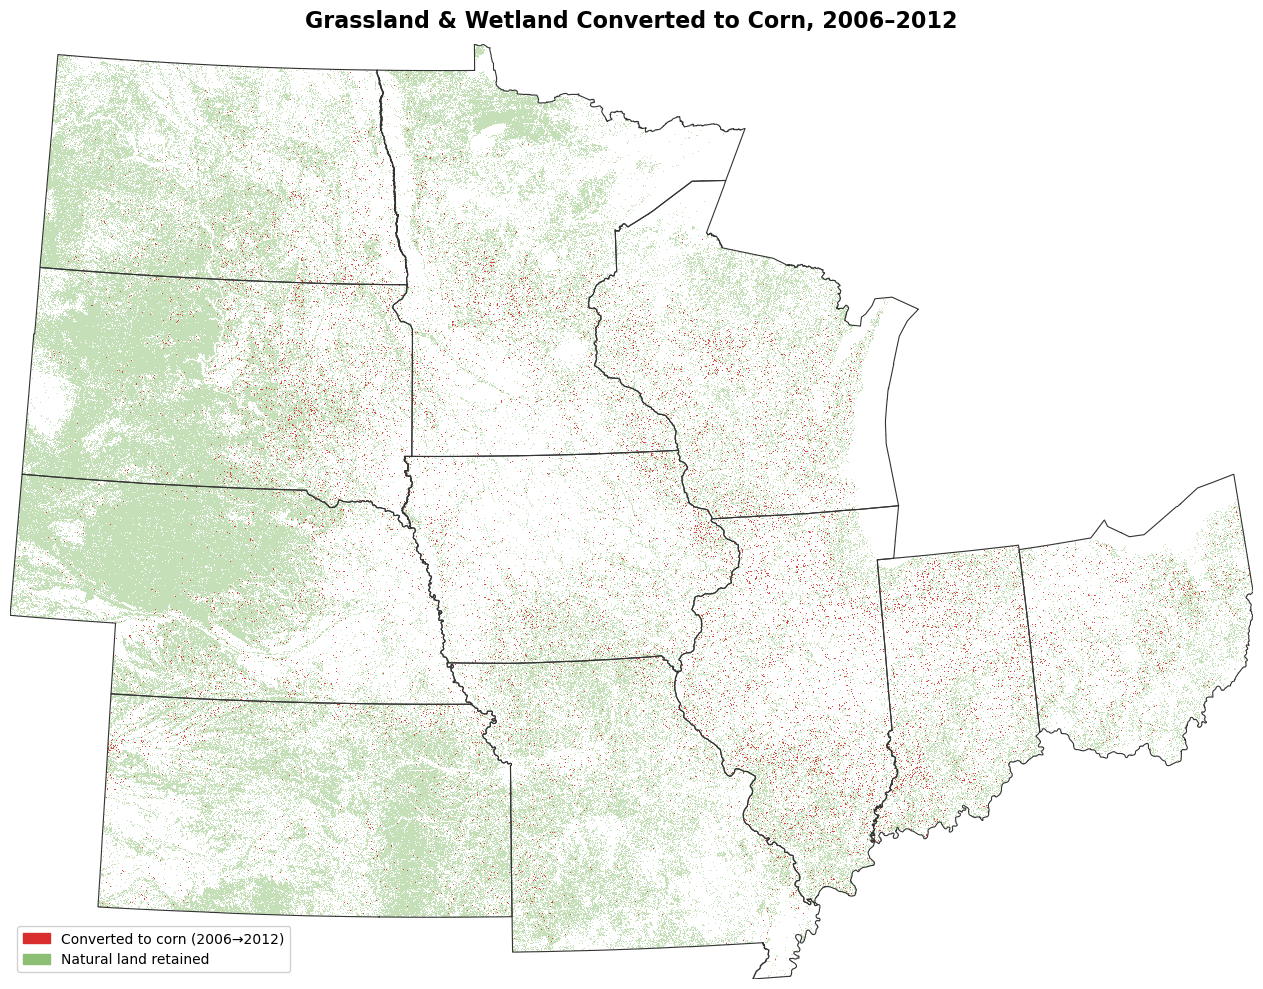

In [8]:
# Step 5: Visualize 
print("\nStep 5: Generating map...")
 
# Downsample for plotting — full 30m mosaic is too large to plot directly.
# We read every Nth pixel to produce a manageable array.
# This does NOT affect analysis — only the display resolution.
PLOT_DOWNSAMPLE = 5   # read every 5th pixel -> effective 150m display resolution
 
with rasterio.open(conversion_path) as src:
    data = src.read(
        1,
        out_shape=(
            src.height // PLOT_DOWNSAMPLE,
            src.width  // PLOT_DOWNSAMPLE
        ),
        resampling=Resampling.nearest
    )
    extent = [
        src.bounds.left, src.bounds.right,
        src.bounds.bottom, src.bounds.top
    ]
 
# Color mapping
# 0 = background/no data -> transparent
# 1 = converted          -> red/orange (alarming)
# 2 = retained natural   -> muted green
color_map = {
    0: (1, 1, 1, 0),        # transparent
    1: (0.85, 0.18, 0.18, 0.9),   # red — converted
    2: (0.55, 0.75, 0.45, 0.5),   # green — retained
}
 
# Build RGBA image
rgb = np.zeros((*data.shape, 4), dtype=float)
for val, color in color_map.items():
    mask = data == val
    rgb[mask] = color
 
# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
 
ax.imshow(
    rgb,
    extent=extent,
    origin='upper',
    interpolation='none'
)
 
# State boundaries overlay
county_shp = gpd.read_file('../data/raw-data/tl_2012_us_county.zip')
state_shp  = county_shp.dissolve(by='STATEFP')
corn_belt_fips = [
    '17', '18', '19', '20', '27', '29', '31', '38', '39', '46', '55'
]
state_shp = state_shp[state_shp.index.isin(corn_belt_fips)]
state_shp = state_shp.to_crs(TARGET_CRS)
state_shp.boundary.plot(ax=ax, color='#333333', linewidth=0.8)
 
# Legend
legend_patches = [
    mpatches.Patch(color=(0.85, 0.18, 0.18), label='Converted to corn (2006→2012)'),
    mpatches.Patch(color=(0.55, 0.75, 0.45), label='Natural land retained'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10,
          framealpha=0.9)
 
# Annotations
ax.set_title(
    'Grassland & Wetland Converted to Corn, 2006–2012',
    fontsize=16, fontweight='bold', pad=12
)
ax.set_xlabel(
    f'Red pixels = land that was grassland or wetland in 2006 and became corn by 2012\n'
    f'Total converted: {converted_ha:,.0f} hectares  |  '
    f'Conversion rate: {converted_ha/(converted_ha+retained_ha)*100:.1f}% of natural land lost',
    fontsize=9, color='#444444'
)
ax.axis('off')
 
plt.tight_layout()
map_path = '../outputs/cdl_conversion_map.png'
plt.savefig(map_path, dpi=150, bbox_inches='tight')
print(f"\nMap saved to {map_path}")
plt.show()
